In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'

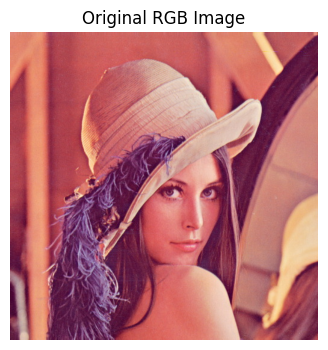

In [2]:
img_bgr = cv2.imread('lena.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img_rgb)
plt.title('Original RGB Image')
plt.axis('off')
plt.show()

In [3]:
# =====================================================
# DIP Lab: RGB Channel Histograms (Lena Image)
# Separate R, G, B Histograms with Analysis
# =====================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# =====================================================
# 1. Load Lena Image (Color)
# =====================================================

img_bgr = cv2.imread('lena.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Split into R, G, B channels
r_channel = img_rgb[:, :, 0]
g_channel = img_rgb[:, :, 1]
b_channel = img_rgb[:, :, 2]

print(f"Image loaded: {img_rgb.shape} (Height × Width × Channels)")


Image loaded: (512, 512, 3) (Height × Width × Channels)


In [5]:
# =====================================================
# 2. Compute Histograms for Each Channel
# =====================================================
def compute_hist(channel):
    return cv2.calcHist([channel], [0], None, [256], [0, 256])

hist_r = compute_hist(r_channel)
hist_g = compute_hist(g_channel)
hist_b = compute_hist(b_channel)


In [6]:
# =====================================================
# 3. Channel Statistics
# =====================================================
def channel_stats(channel, name, color):
    mean = np.mean(channel)
    std = np.std(channel)
    peak = np.argmax(channel)
    print(f"{name:5} Channel | Mean: {mean:6.1f} | Std: {std:5.1f} | Peak Intensity: {peak:3}")
    return mean, std

print("\n" + "="*70)
print("RGB CHANNEL STATISTICS")
print("-"*70)
mean_r, std_r = channel_stats(r_channel, "Red",   'red')
mean_g, std_g = channel_stats(g_channel, "Green", 'green')
mean_b, std_b = channel_stats(b_channel, "Blue",  'blue')
print("-"*70)


RGB CHANNEL STATISTICS
----------------------------------------------------------------------
Red   Channel | Mean:  179.7 | Std:  49.0 | Peak Intensity: 4511
Green Channel | Mean:   99.6 | Std:  52.9 | Peak Intensity: 139892
Blue  Channel | Mean:  105.4 | Std:  33.7 | Peak Intensity: 188530
----------------------------------------------------------------------


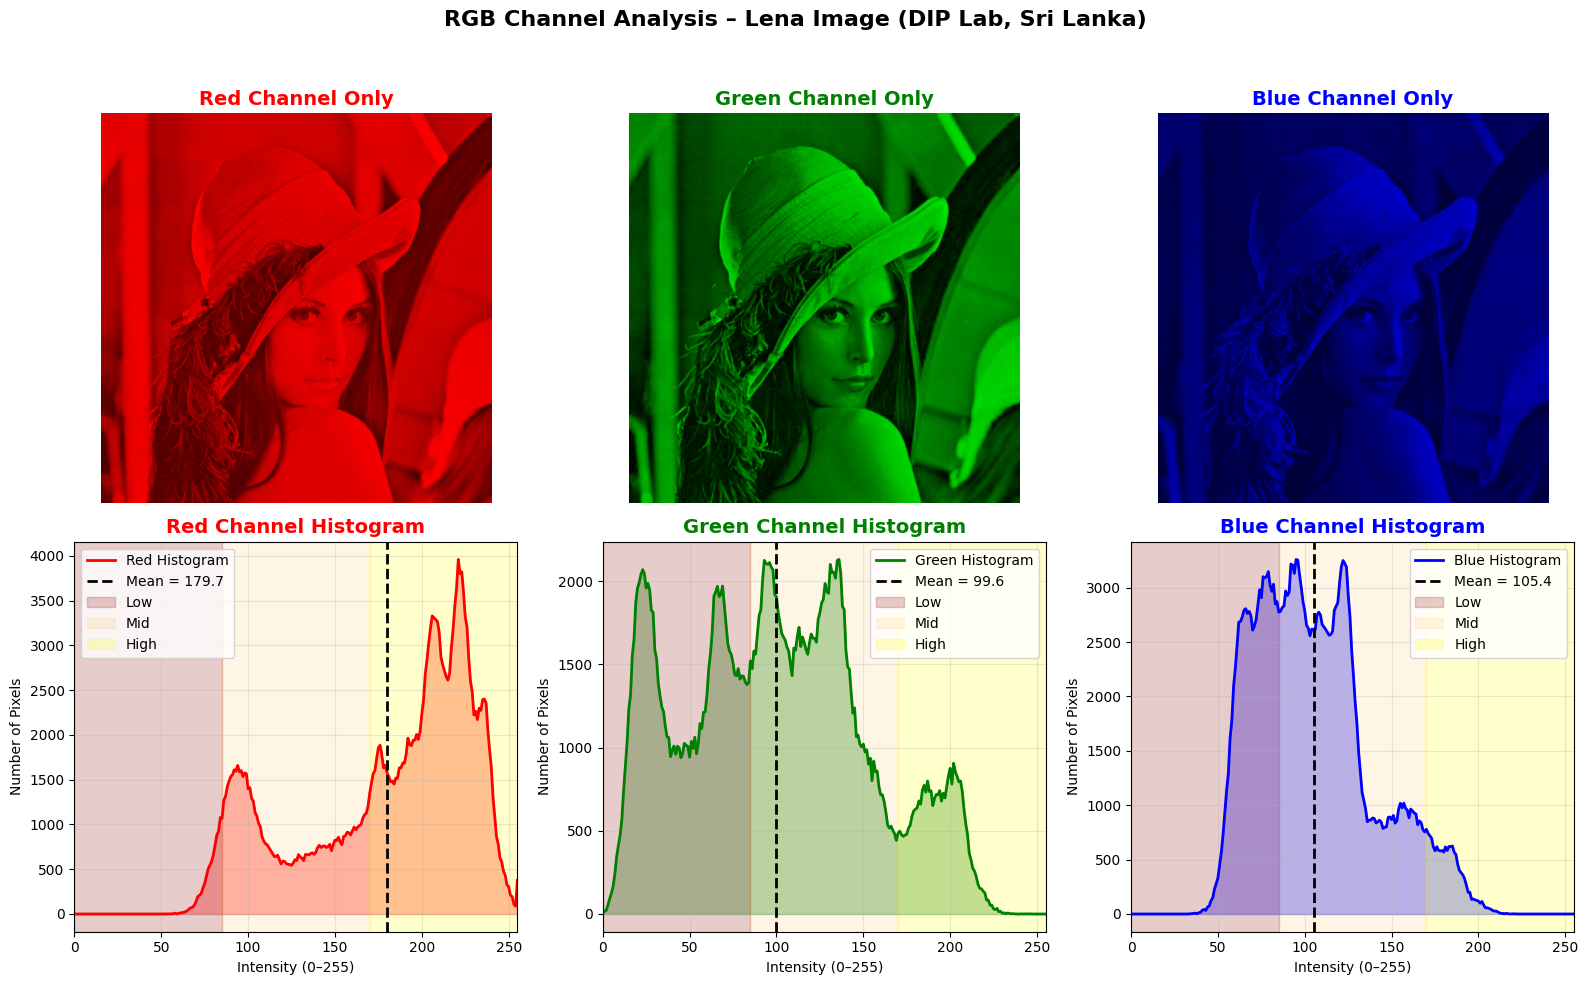

In [7]:
# =====================================================
# 4. Plot: Three Separate Histograms
# =====================================================
plt.figure(figsize=(16, 10))

channels = [
    (r_channel, hist_r, 'Red',   'red',    mean_r),
    (g_channel, hist_g, 'Green', 'green',  mean_g),
    (b_channel, hist_b, 'Blue',  'blue',   mean_b)
]

for i, (ch, hist, name, color, mean_val) in enumerate(channels):
    # --- Channel Image ---
    plt.subplot(2, 3, i+1)
    # Create masked image: show only this channel
    masked = np.zeros_like(img_rgb)
    masked[:, :, i] = ch
    plt.imshow(masked)
    plt.title(f'{name} Channel Only', fontsize=14, fontweight='bold', color=color)
    plt.axis('off')

    # --- Histogram ---
    plt.subplot(2, 3, i+4)
    plt.plot(hist, color=color, linewidth=2, label=f'{name} Histogram')
    plt.fill_between(range(256), hist.flatten(), color=color, alpha=0.3)
    
    # Mean line
    plt.axvline(mean_val, color='black', linestyle='--', linewidth=2, 
                label=f'Mean = {mean_val:.1f}')
    
    # Intensity zones
    plt.axvspan(0, 85, color='darkred', alpha=0.2, label='Low')
    plt.axvspan(85, 170, color='orange', alpha=0.1, label='Mid')
    plt.axvspan(170, 255, color='yellow', alpha=0.2, label='High')
    
    plt.title(f'{name} Channel Histogram', fontsize=14, fontweight='bold', color=color)
    plt.xlabel('Intensity (0–255)')
    plt.ylabel('Number of Pixels')
    plt.xlim(0, 255)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.suptitle('RGB Channel Analysis – Lena Image (DIP Lab, Sri Lanka)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

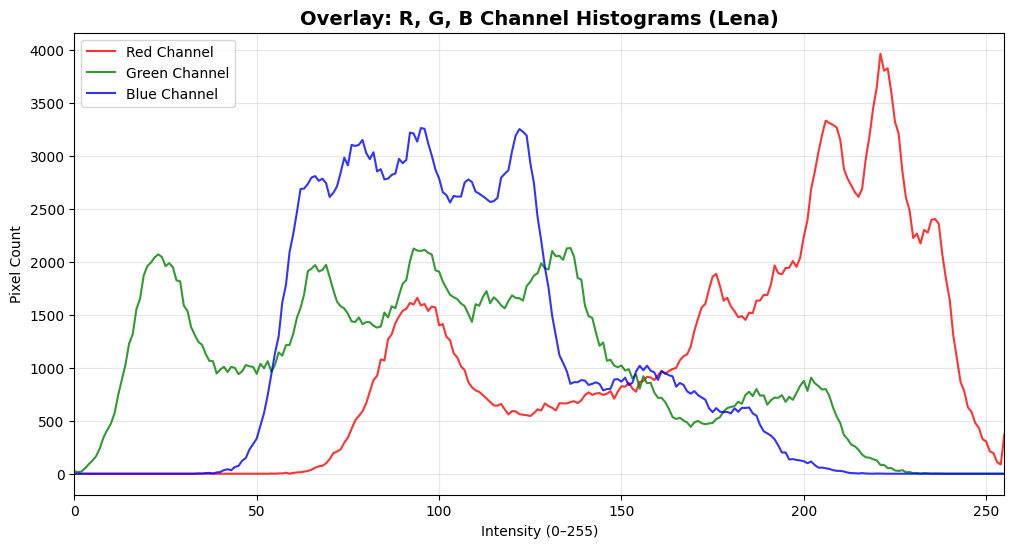

In [8]:
# =====================================================
# 5. Bonus: Overlay All 3 Histograms in One Plot
# =====================================================
plt.figure(figsize=(12, 6))
plt.plot(hist_r, color='red',   alpha=0.8, label='Red Channel',   linewidth=1.5)
plt.plot(hist_g, color='green', alpha=0.8, label='Green Channel', linewidth=1.5)
plt.plot(hist_b, color='blue',  alpha=0.8, label='Blue Channel',  linewidth=1.5)

plt.title('Overlay: R, G, B Channel Histograms (Lena)', fontsize=14, fontweight='bold')
plt.xlabel('Intensity (0–255)')
plt.ylabel('Pixel Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 255)
plt.show()

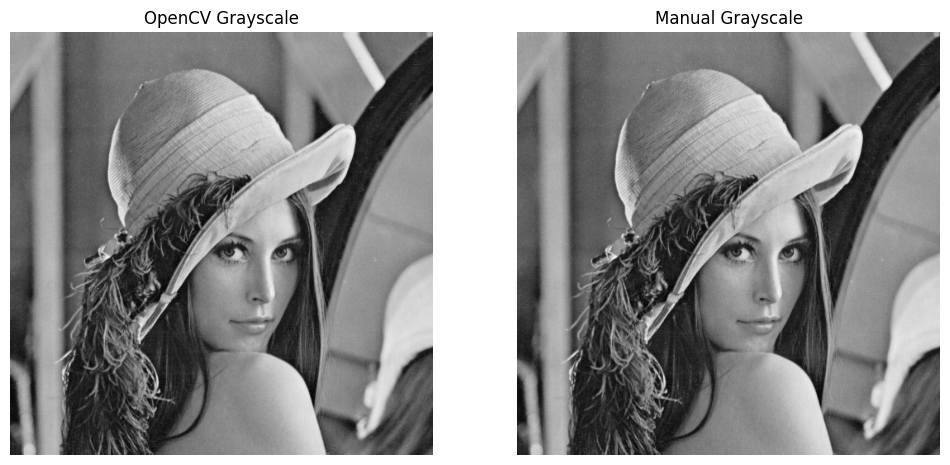

In [9]:
gray_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Manual conversion
gray_manual = (0.299 * img_rgb[:,:,0] + 
               0.587 * img_rgb[:,:,1] + 
               0.114 * img_rgb[:,:,2]).astype('uint8')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(gray_cv, cmap='gray')
ax[0].set_title('OpenCV Grayscale')
ax[1].imshow(gray_manual, cmap='gray')
ax[1].set_title('Manual Grayscale')
for a in ax:
    a.axis('off')
plt.show()

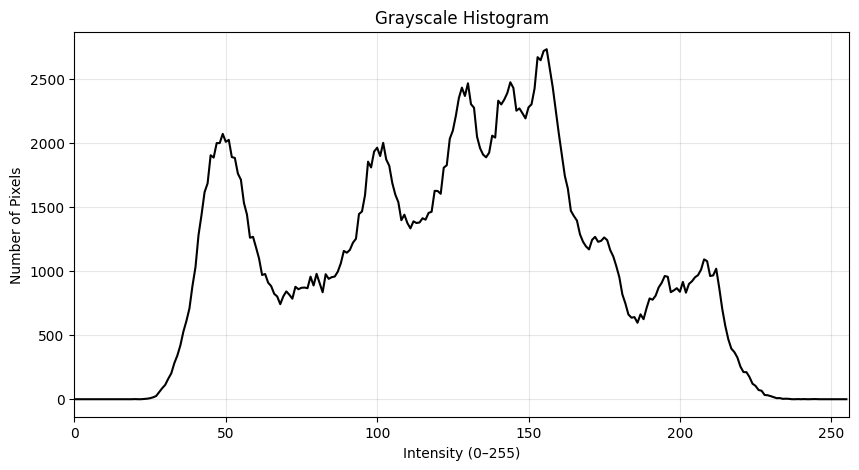

In [10]:
hist = cv2.calcHist([gray_cv], [0], None, [256], [0, 256])

plt.figure(figsize=(10, 5))
plt.plot(hist, color='black')
plt.title('Grayscale Histogram')
plt.xlabel('Intensity (0–255)')
plt.ylabel('Number of Pixels')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)
plt.show()

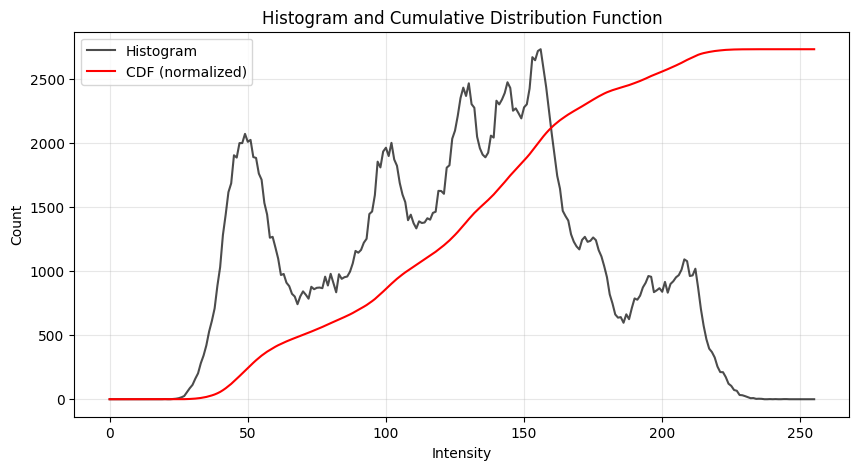

In [11]:
# Cumulative Histogram (CDF)
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max() / cdf.max()  # Scale for overlay

plt.figure(figsize=(10, 5))
plt.plot(hist, color='black', alpha=0.7, label='Histogram')
plt.plot(cdf_normalized, color='red', label='CDF (normalized)')
plt.title('Histogram and Cumulative Distribution Function')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

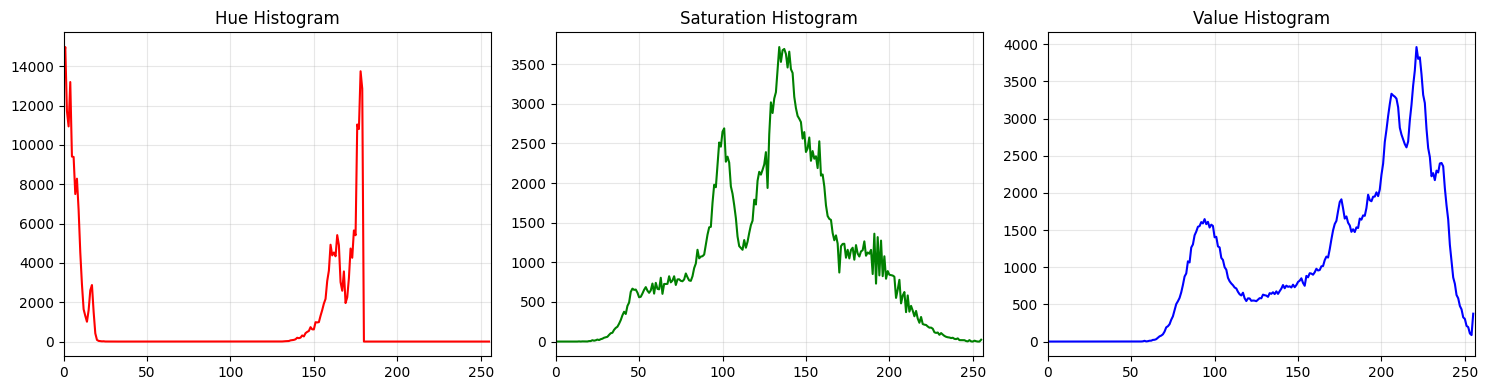

In [12]:
# RGB to HSV & Channel Histograms
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
channels = [h, s, v]
names = ['Hue', 'Saturation', 'Value']
colors = ['red', 'green', 'blue']

for i in range(3):
    hist_ch = cv2.calcHist([channels[i]], [0], None, [256], [0, 256])
    ax[i].plot(hist_ch, color=colors[i])
    ax[i].set_title(f'{names[i]} Histogram')
    ax[i].set_xlim([0, 256])
    ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

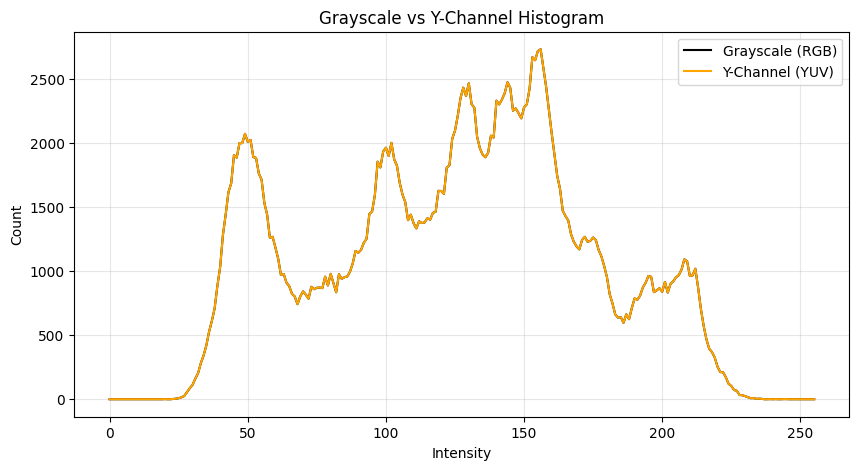

In [13]:
# //Bonus: YUV Color Space & Y-Channel Histogram
yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
y, u, v = cv2.split(yuv)

hist_y = cv2.calcHist([y], [0], None, [256], [0, 256])

plt.figure(figsize=(10, 5))
plt.plot(hist, color='black', label='Grayscale (RGB)')
plt.plot(hist_y, color='orange', label='Y-Channel (YUV)')
plt.title('Grayscale vs Y-Channel Histogram')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


EXPOSURE STATISTICS
--------------------------------------------------------------------------------
Low Exp.     | Mean:   49.3 | Shadows:  46.1% | Highlights:   0.0% | → Underexposed
Good Exp.    | Mean:  124.2 | Shadows:   8.2% | Highlights:   6.4% | → Good
High Exp.    | Mean:  212.1 | Shadows:   0.0% | Highlights:  68.5% | → Overexposed
--------------------------------------------------------------------------------


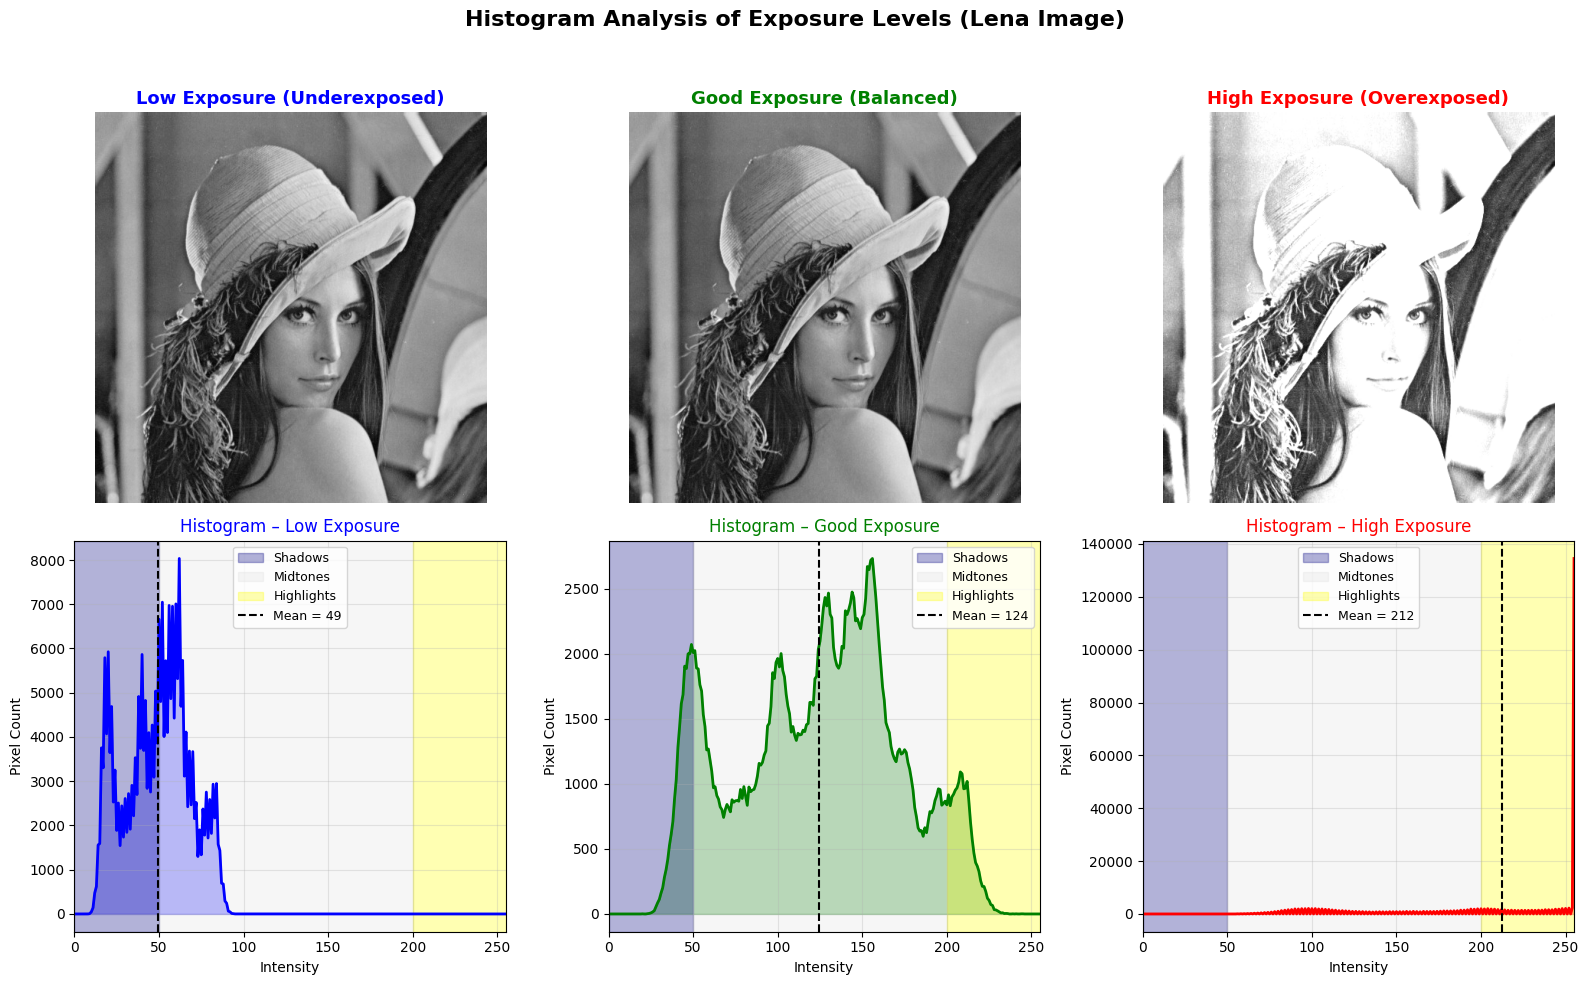

In [14]:
# Histogram Analysis
# =====================================================
# High, Good, and Low Exposure Images (Lena)
# =====================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request


img_bgr = cv2.imread('lena.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# =====================================================
# 1. Create Exposure Variants
# =====================================================
def adjust_exposure(img, factor):
    """Multiply pixel values (simulate exposure change)"""
    return np.clip(img * factor, 0, 255).astype('uint8')

# Original is "Good" exposure
good = gray.copy()

# High exposure (overexposed)
high = adjust_exposure(gray, 2.0)

# Low exposure (underexposed)
low = adjust_exposure(gray, 0.4)

# =====================================================
# 2. Compute Histograms
# =====================================================
def compute_hist(img):
    return cv2.calcHist([img], [0], None, [256], [0, 256])

hist_good = compute_hist(good)
hist_high = compute_hist(high)
hist_low = compute_hist(low)

# =====================================================
# 3. Statistics
# =====================================================
def exposure_stats(img, name):
    mean = np.mean(img)
    shadows = np.sum(img < 50) / img.size * 100
    highlights = np.sum(img > 200) / img.size * 100
    status = "Overexposed" if highlights > 35 else "Underexposed" if shadows > 35 else "Good"
    print(f"{name:12} | Mean: {mean:6.1f} | Shadows: {shadows:5.1f}% | Highlights: {highlights:5.1f}% | → {status}")
    return mean, shadows, highlights, status

print("\nEXPOSURE STATISTICS")
print("-" * 80)
exposure_stats(low,  "Low Exp.")
exposure_stats(good, "Good Exp.")
exposure_stats(high, "High Exp.")
print("-" * 80)

# =====================================================
# 4. Plot: 3 Histograms in One Figure
# =====================================================
plt.figure(figsize=(16, 10))

titles = ['Low Exposure (Underexposed)', 'Good Exposure (Balanced)', 'High Exposure (Overexposed)']
images = [low, good, high]
hists = [hist_low, hist_good, hist_high]
colors = ['blue', 'green', 'red']
means = [np.mean(low), np.mean(good), np.mean(high)]

for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=13, fontweight='bold', color=colors[i])
    plt.axis('off')

    # Histogram subplot
    plt.subplot(2, 3, i+4)
    plt.plot(hists[i], color=colors[i], linewidth=2)
    plt.fill_between(range(256), hists[i].flatten(), color=colors[i], alpha=0.3)
    
    # Exposure zones
    plt.axvspan(0, 50, color='navy', alpha=0.3, label='Shadows')
    plt.axvspan(50, 200, color='lightgray', alpha=0.2, label='Midtones')
    plt.axvspan(200, 255, color='yellow', alpha=0.3, label='Highlights')
    
    # Mean line
    plt.axvline(means[i], color='black', linestyle='--', linewidth=1.5, 
                label=f'Mean = {means[i]:.0f}')
    
    plt.title(f'Histogram – {titles[i].split(" ")[0]} Exposure', color=colors[i])
    plt.xlabel('Intensity')
    plt.ylabel('Pixel Count')
    plt.xlim(0, 255)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)

plt.suptitle('Histogram Analysis of Exposure Levels (Lena Image)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


CONTRAST STATISTICS
------------------------------------------------------------------------------------------
Low Contrast | Std Dev:   14.4 | Range: 0.267 | Michelson: 0.213 | → Low Contrast
Good Contrast | Std Dev:   47.9 | Range: 0.882 | Michelson: 0.708 | → Medium (Good)
High Contrast | Std Dev:   91.3 | Range: 1.000 | Michelson: 1.000 | → High Contrast
------------------------------------------------------------------------------------------


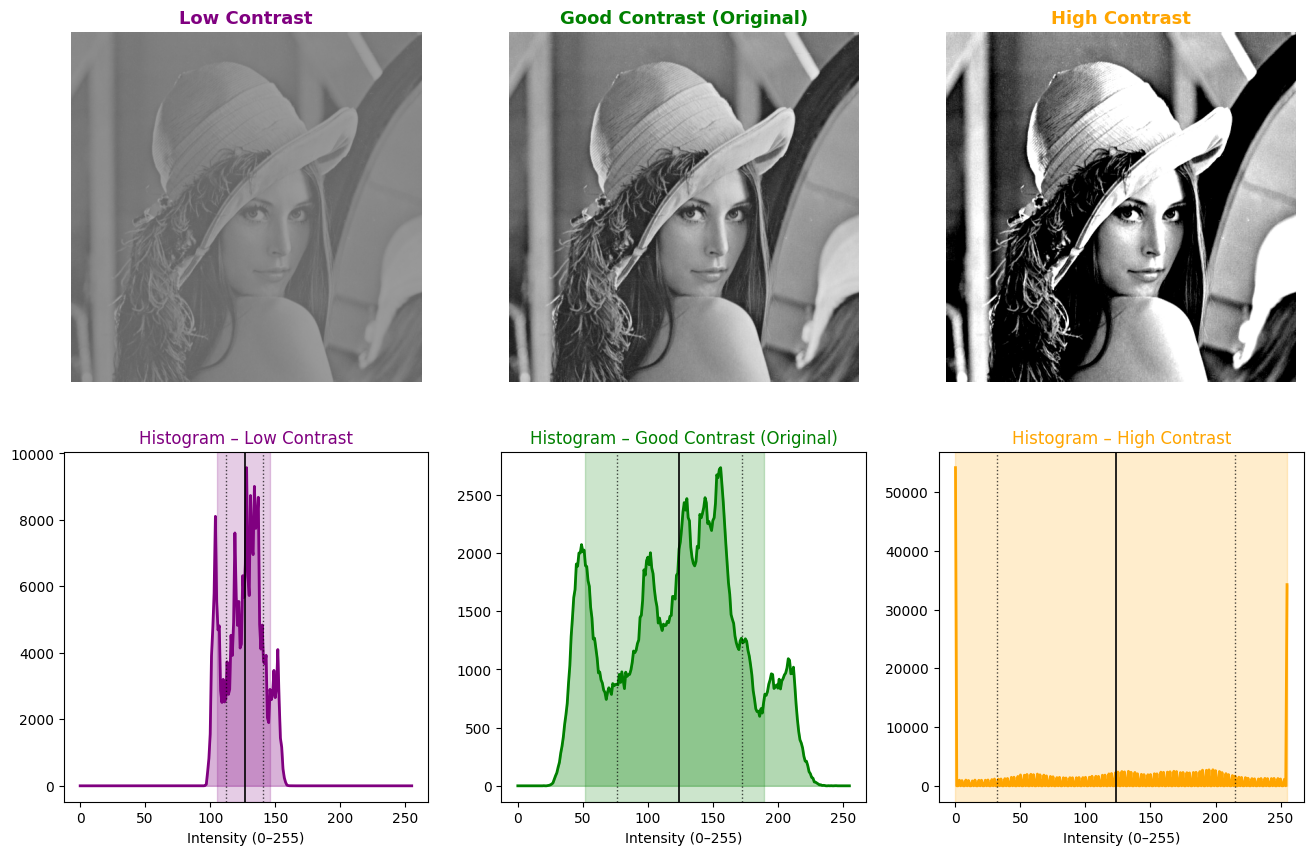

In [15]:
# =====================================================
# High, Good, and Low Contrast Images (Lena)
# =====================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request


img_bgr = cv2.imread('lena.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# =====================================================
# 1. Create Contrast Variants
# =====================================================
def adjust_contrast(img, alpha):
    """
    Apply contrast: new = alpha * (img - 128) + 128
    alpha > 1 → high contrast, alpha < 1 → low contrast
    """
    return np.clip(alpha * (img.astype(np.float32) - 128) + 128, 0, 255).astype('uint8')

# Original is "Good" contrast
good = gray.copy()

# High contrast (alpha = 2.5)
high = adjust_contrast(gray, 2.5)

# Low contrast (alpha = 0.3)
low = adjust_contrast(gray, 0.3)

# =====================================================
# 2. Compute Histograms
# =====================================================
def compute_hist(img):
    return cv2.calcHist([img], [0], None, [256], [0, 256])

hist_good = compute_hist(good)
hist_high = compute_hist(high)
hist_low = compute_hist(low)

# =====================================================
# 3. Contrast Statistics
# =====================================================
def contrast_stats(img, name):
    std = np.std(img)
    dynamic_range = (img.max() - img.min()) / 255.0
    michelson = (np.percentile(img, 99) - np.percentile(img, 1)) / \
                (np.percentile(img, 99) + np.percentile(img, 1) + 1e-6)
    
    if std < 30:
        label = "Low Contrast"
    elif std < 60:
        label = "Medium (Good)"
    else:
        label = "High Contrast"
    
    print(f"{name:12} | Std Dev: {std:6.1f} | Range: {dynamic_range:5.3f} | Michelson: {michelson:5.3f} | → {label}")
    return std, dynamic_range, michelson, label

print("\nCONTRAST STATISTICS")
print("-" * 90)
contrast_stats(low,  "Low Contrast")
contrast_stats(good, "Good Contrast")
contrast_stats(high, "High Contrast")
print("-" * 90)

# =====================================================
# 4. Plot: 3 Histograms + Images
# =====================================================
plt.figure(figsize=(16, 10))

titles = ['Low Contrast', 'Good Contrast (Original)', 'High Contrast']
images = [low, good, high]
hists = [hist_low, hist_good, hist_high]
colors = ['purple', 'green', 'orange']
stds = [np.std(low), np.std(good), np.std(high)]

for i in range(3):
    # Image
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=13, fontweight='bold', color=colors[i])
    plt.axis('off')

    # Histogram
    plt.subplot(2, 3, i+4)
    plt.plot(hists[i], color=colors[i], linewidth=2)
    plt.fill_between(range(256), hists[i].flatten(), color=colors[i], alpha=0.3)
    
    # Contrast zones (spread)
    p10 = np.percentile(images[i], 10)
    p90 = np.percentile(images[i], 90)
    plt.axvspan(p10, p90, color=colors[i], alpha=0.2, label='90% Intensity Range')
    
    # Std Dev lines
    mean_val = np.mean(images[i])
    plt.axvline(mean_val, color='black', linestyle='-', linewidth=1.2)
    plt.axvline(mean_val - stds[i], color='black', linestyle=':', linewidth=1, alpha=0.7)
    plt.axvline(mean_val + stds[i], color='black', linestyle=':', linewidth=1, alpha=0.7, 
                label=f'±1σ = {stds[i]:.0f}')
    
    plt.title(f'Histogram – {titles[i]}', color=colors[i])
    plt.xlabel('Intensity (0–255)')
    plt


BRIGHTNESS STATISTICS
----------------------------------------------------------------------------------------------------
Low Bright.    | Mean:   34.7 | Median:   29.0 | Shadows:  67.3% | Highlights:   0.0% | → Low Brightness (Dark)
Good Bright.   | Mean:  124.2 | Median:  129.0 | Shadows:   8.2% | Highlights:   6.4% | → Good Brightness
High Bright.   | Mean:  217.0 | Median:  229.0 | Shadows:   0.0% | Highlights:  68.5% | → High Brightness (Over-bright)
----------------------------------------------------------------------------------------------------


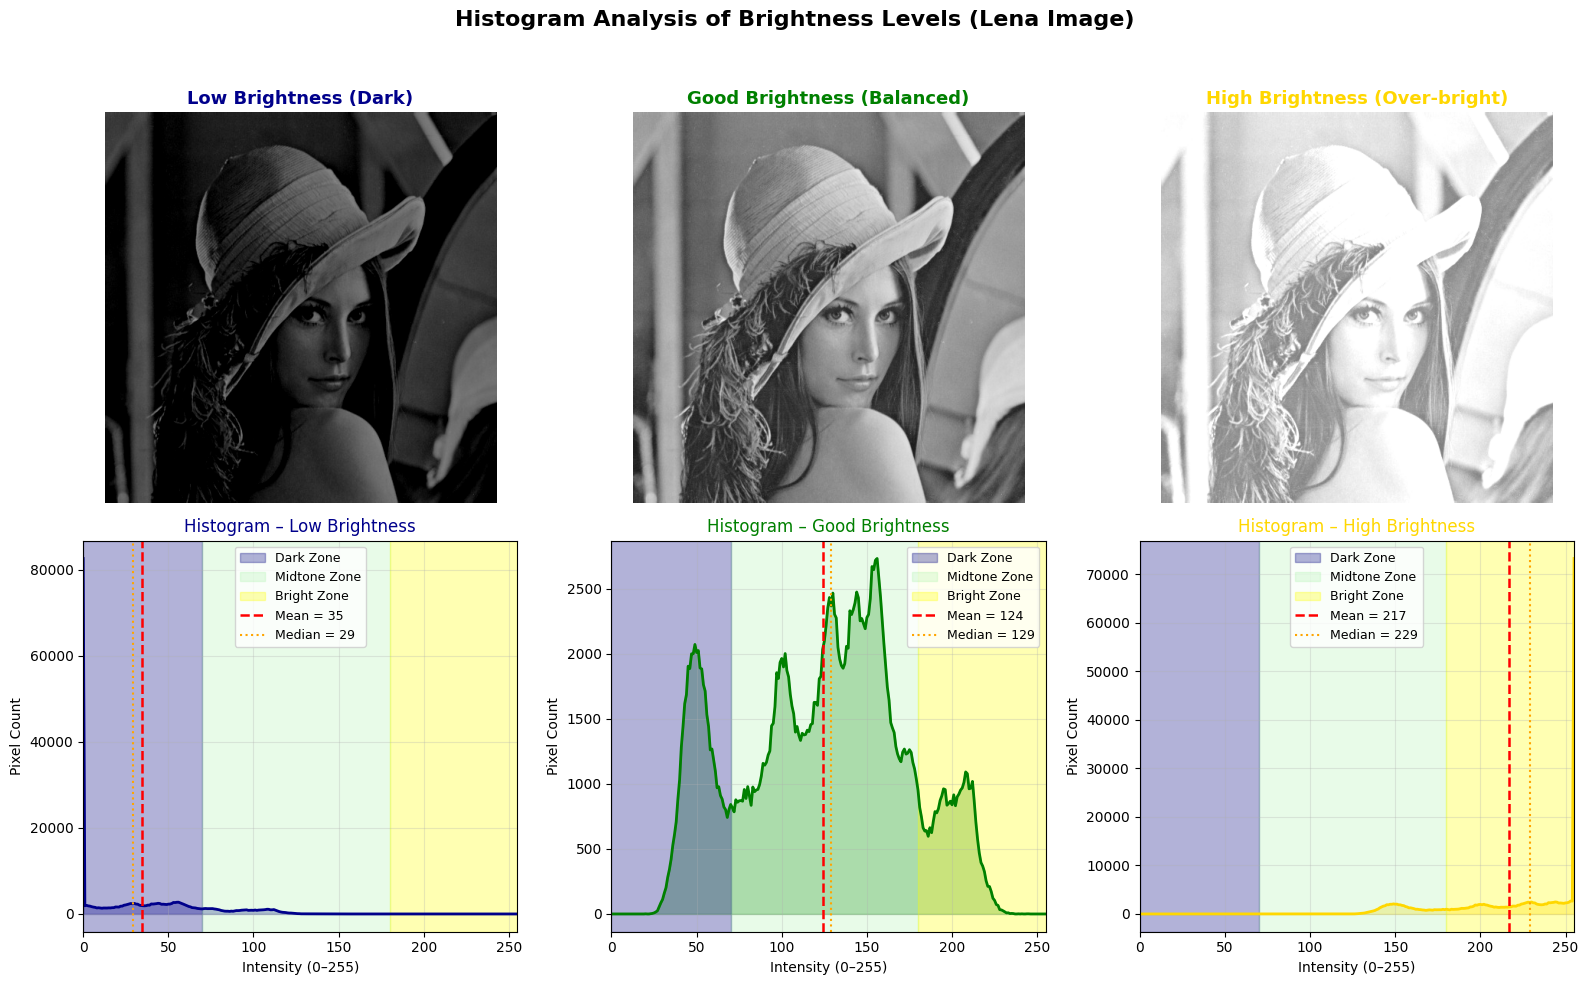

In [16]:
# =====================================================
# High, Good, and Low Brightness Images (Lena)
# =====================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request


img_bgr = cv2.imread('lena.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# =====================================================
# 1. Create Brightness Variants
# =====================================================
def adjust_brightness(img, delta):
    """
    Add constant to all pixels to change brightness
    delta > 0 → brighter, delta < 0 → darker
    """
    return np.clip(img.astype(np.int16) + delta, 0, 255).astype('uint8')

# Original is "Good" brightness
good = gray.copy()

# High brightness (add +100)
high = adjust_brightness(gray, +100)

# Low brightness (add -100)
low = adjust_brightness(gray, -100)

# =====================================================
# 2. Compute Histograms
# =====================================================
def compute_hist(img):
    return cv2.calcHist([img], [0], None, [256], [0, 256])

hist_good = compute_hist(good)
hist_high = compute_hist(high)
hist_low = compute_hist(low)

# =====================================================
# 3. Brightness Statistics
# =====================================================
def brightness_stats(img, name):
    mean = np.mean(img)
    median = np.median(img)
    shadows = np.sum(img < 50) / img.size * 100
    highlights = np.sum(img > 200) / img.size * 100
    
    if mean < 70:
        label = "Low Brightness (Dark)"
    elif mean < 180:
        label = "Good Brightness"
    else:
        label = "High Brightness (Over-bright)"
    
    print(f"{name:14} | Mean: {mean:6.1f} | Median: {median:6.1f} | Shadows: {shadows:5.1f}% | Highlights: {highlights:5.1f}% | → {label}")
    return mean, median, shadows, highlights, label

print("\nBRIGHTNESS STATISTICS")
print("-" * 100)
brightness_stats(low,  "Low Bright.")
brightness_stats(good, "Good Bright.")
brightness_stats(high, "High Bright.")
print("-" * 100)

# =====================================================
# 4. Plot: 3 Histograms + Images
# =====================================================
plt.figure(figsize=(16, 10))

titles = ['Low Brightness (Dark)', 'Good Brightness (Balanced)', 'High Brightness (Over-bright)']
images = [low, good, high]
hists = [hist_low, hist_good, hist_high]
colors = ['darkblue', 'green', 'gold']
means = [np.mean(low), np.mean(good), np.mean(high)]

for i in range(3):
    # Image
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=13, fontweight='bold', color=colors[i])
    plt.axis('off')

    # Histogram
    plt.subplot(2, 3, i+4)
    plt.plot(hists[i], color=colors[i], linewidth=2)
    plt.fill_between(range(256), hists[i].flatten(), color=colors[i], alpha=0.3)
    
    # Brightness zones
    plt.axvspan(0, 70, color='navy', alpha=0.3, label='Dark Zone')
    plt.axvspan(70, 180, color='lightgreen', alpha=0.2, label='Midtone Zone')
    plt.axvspan(180, 255, color='yellow', alpha=0.3, label='Bright Zone')
    
    # Mean & Median lines
    mean_val = means[i]
    median_val = np.median(images[i])
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.8, label=f'Mean = {mean_val:.0f}')
    plt.axvline(median_val, color='orange', linestyle=':', linewidth=1.5, label=f'Median = {median_val:.0f}')
    
    plt.title(f'Histogram – {titles[i].split(" ")[0]} Brightness', color=colors[i])
    plt.xlabel('Intensity (0–255)')
    plt.ylabel('Pixel Count')
    plt.xlim(0, 255)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)

plt.suptitle('Histogram Analysis of Brightness Levels (Lena Image)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()